In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import regularizers

from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [ ]:
csv_path = '/content/drive/MyDrive/dataset/quantum_regression_dataset.csv'

# Load the dataset
df = pd.read_csv(csv_path)
data = df.to_numpy()

# Display shape
print("Shape:", df.shape)
df.head()

Shape: (98664, 18)


,q_real_0,q_real_1,q_real_2,q_real_3,q_real_4,q_real_5,q_real_6,q_real_7,R_p,g_p,Temp,log_kappa_cloud,log_P_cloud,log_H2O,log_CO2,log_CO,log_CH4,log_NH3
0,0.326759,-0.376410,0.018010,0.257298,0.249678,-0.687701,-0.358926,0.144632,1.658348,17.176982,3327.875478,-3.855474,-3.844470,-8.889865,-4.018888,-3.195541,-7.868857,-5.895533
1,0.390267,-0.775890,0.057996,0.001370,0.231710,-0.379083,-0.091832,-0.191034,0.258443,16.036432,2034.071133,-3.014919,-2.962217,-3.225697,-2.038615,-5.329029,-3.169883,-3.206833
2,0.118149,-0.693368,0.030770,0.099597,0.286569,-0.608399,-0.144325,-0.145995,0.503774,9.066010,1712.661454,-2.246068,-1.677456,-3.993484,-2.895214,-7.397882,-8.908273,-7.172669
3,0.308928,-0.376906,0.070070,0.276563,0.318926,-0.693181,-0.304230,-0.079621,0.562965,7.254639,3287.260930,-1.086659,-3.761693,-8.448541,-3.301345,-4.516020,-7.289866,-7.753208
4,0.310015,-0.517832,0.068154,0.172262,0.285593,-0.644275,-0.318354,-0.058468,0.745250,35.230361,2895.010899,-1.323324,-1.794849,-8.350682,-4.666140,-6.680365,-6.197769,-5.475105


In [ ]:
df.describe()

,q_real_0,q_real_1,q_real_2,q_real_3,q_real_4,q_real_5,q_real_6,q_real_7,R_p,g_p,Temp,log_kappa_cloud,log_P_cloud,log_H2O,log_CO2,log_CO,log_CH4,log_NH3
count,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000
mean,0.385011,-0.690265,-0.009520,-0.064757,0.151091,-0.202131,0.098274,0.019797,1.060991,22.680367,1990.529089,-3.203587,-1.506352,-5.497066,-5.490777,-5.500600,-5.500026,-5.508865
std,0.168548,0.138050,0.160763,0.180598,0.130655,0.234765,0.250466,0.237570,0.542885,10.043365,866.480792,2.187283,1.445999,2.021719,2.020946,2.027659,2.023330,2.020505
min,-0.301088,-0.963188,-0.454725,-0.667747,-0.270887,-0.744411,-0.584613,-0.317100,0.100042,5.000412,500.059513,-6.999982,-3.999971,-8.999924,-8.999969,-8.999911,-8.999990,-8.999985
25%,0.301946,-0.773800,-0.126458,-0.178881,0.057765,-0.371297,-0.071743,-0.156878,0.593661,14.036827,1238.898762,-5.087822,-2.762471,-7.250021,-7.239419,-7.264763,-7.260083,-7.261356
50%,0.412431,-0.725418,-0.011122,-0.019974,0.150505,-0.167967,0.142788,-0.053006,1.061147,22.724996,1986.033911,-3.215291,-1.504305,-5.488896,-5.485339,-5.499874,-5.502937,-5.508495
75%,0.497727,-0.642495,0.114953,0.069566,0.237824,-0.052334,0.304758,0.135131,1.531775,31.344526,2737.571477,-1.317402,-0.255494,-3.753459,-3.741738,-3.740803,-3.745523,-3.763974
max,0.769482,0.190624,0.529325,0.287937,0.667619,0.355180,0.510730,0.969094,1.999990,39.999593,3499.933503,0.599861,0.999957,-2.000011,-2.000260,-2.000041,-2.000107,-2.000021


In [ ]:
target_cols = ["log_H2O", "log_CO2", "log_CO", "log_CH4", "log_NH3"]
X = df.drop(columns=target_cols)
y = df[target_cols]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (98664, 13)
y shape: (98664, 5)


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [ ]:
# Scale inputs
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_val   = scaler_X.transform(X_val)
X_test  = scaler_X.transform(X_test)

# Scale outputs (independently for each parameter!)
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train)
y_val   = scaler_y.transform(y_val)
y_test  = scaler_y.transform(y_test)

In [ ]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dense(len(target_cols))
])


model.compile(optimizer=Adam(learning_rate=0.0005),
              loss='mse',
              metrics=['mae'])


model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,597 (182.02 KB)

 Trainable params: 45,829 (179.02 KB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=300,
    batch_size=128,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)


Epoch 1/300
617/617 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.5277 - mae: 0.5488 - val_loss: 0.2548 - val_mae: 0.3728 - learning_rate: 5.0000e-04
Epoch 2/300
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2584 - mae: 0.3764 - val_loss: 0.2134 - val_mae: 0.3334 - learning_rate: 5.0000e-04
Epoch 3/300
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2198 - mae: 0.3407 - val_loss: 0.1946 - val_mae: 0.3134 - learning_rate: 5.0000e-04
Epoch 4/300
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1975 - mae: 0.3186 - val_loss: 0.1772 - val_mae: 0.2932 - learning_rate: 5.0000e-04
Epoch 5/300
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1839 - mae: 0.3046 - val_loss: 0.1649 - val_mae: 0.2836 - learning_rate: 5.0000e-04
Epoch 6/300
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1733 - mae: 0.2933 - val_loss: 0.1528 - val_mae: 0.2719 - learning_rate: 5.0000e-04
Epoch 7/300
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1662 - mae: 0.2847 - val_loss: 0.1487 - val_mae: 0.2662

In [ ]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print("Test MSE:", test_loss)
print("Test MAE:", test_mae)

Test MSE: 0.08275055885314941
Test MAE: 0.17925092577934265


In [ ]:
y_pred = model.predict(X_test)
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_test_rescaled = scaler_y.inverse_transform(y_test)

309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
print("\n Metrics per Atmospheric Parameter:")
for i, col in enumerate(target_cols):
    rmse = np.sqrt(mean_squared_error(y_test_rescaled[:, i], y_pred_rescaled[:, i]))
    mae  = mean_absolute_error(y_test_rescaled[:, i], y_pred_rescaled[:, i])
    r2   = r2_score(y_test_rescaled[:, i], y_pred_rescaled[:, i])
    print(f"{col}: RMSE={rmse:.3f}, MAE={mae:.3f}, R²={r2:.3f}")


 Metrics per Atmospheric Parameter:
log_H2O: RMSE=0.579, MAE=0.369, R²=0.919
log_CO2: RMSE=0.263, MAE=0.169, R²=0.983
log_CO: RMSE=0.773, MAE=0.538, R²=0.855
log_CH4: RMSE=0.548, MAE=0.337, R²=0.927
log_NH3: RMSE=0.626, MAE=0.400, R²=0.903


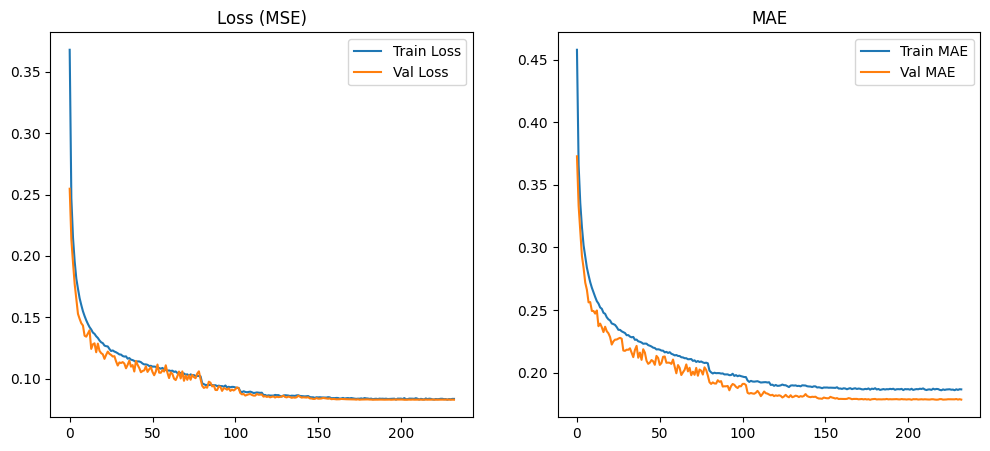

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title("Loss (MSE)")

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.legend(); plt.title("MAE")
plt.show()

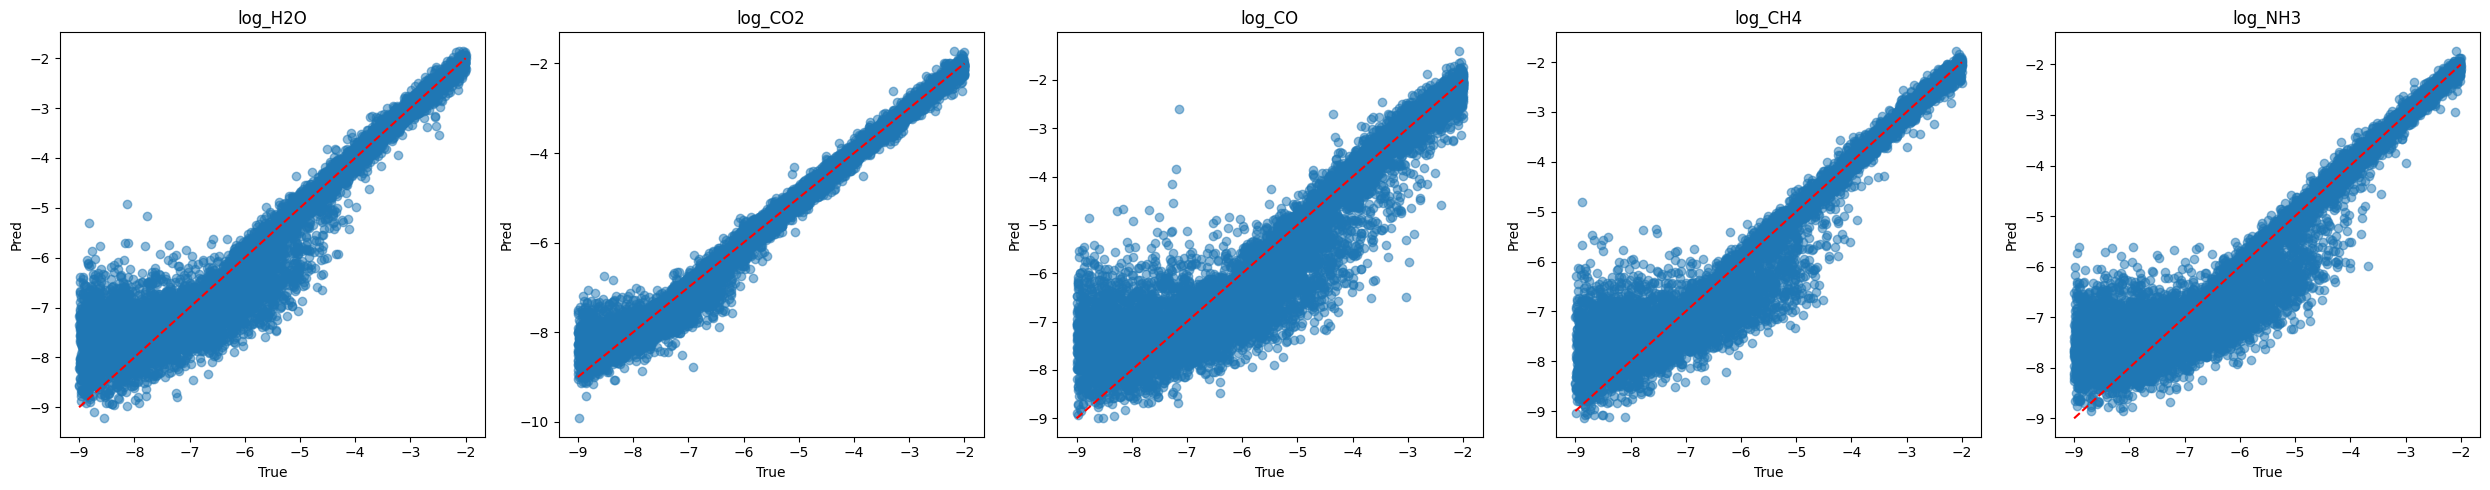

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(25,5))
for i, col in enumerate(target_cols):
    axes[i].scatter(y_test_rescaled[:, i], y_pred_rescaled[:, i], alpha=0.5)
    axes[i].plot([y_test_rescaled[:, i].min(), y_test_rescaled[:, i].max()],
                 [y_test_rescaled[:, i].min(), y_test_rescaled[:, i].max()], 'r--')
    axes[i].set_title(col)
    axes[i].set_xlabel("True")
    axes[i].set_ylabel("Pred")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

# Pick 15 random indices
indices = np.random.choice(len(X_test), size=15, replace=False)

print("\nPredictions on 15 random test samples:\n")

for idx in indices:
    sample = X_test[idx].reshape(1, -1)
    y_pred = model.predict(sample, verbose=0)

    y_pred_rescaled = scaler_y.inverse_transform(y_pred)
    y_true_rescaled = scaler_y.inverse_transform(y_test[idx].reshape(1, -1))

    print(f"Sample {idx}:")
    for i, col in enumerate(target_cols):
        print(f"  {col}: Pred={y_pred_rescaled[0][i]:.3f}, True={y_true_rescaled[0][i]:.3f}")
    print("-"*50)



Predictions on 15 random test samples:

Sample 8850:
  log_H2O: Pred=-2.865, True=-2.850
  log_CO2: Pred=-7.832, True=-7.848
  log_CO: Pred=-2.718, True=-2.131
  log_CH4: Pred=-2.642, True=-2.733
  log_NH3: Pred=-2.428, True=-2.337
--------------------------------------------------
Sample 2973:
  log_H2O: Pred=-2.378, True=-2.442
  log_CO2: Pred=-5.736, True=-5.440
  log_CO: Pred=-7.763, True=-8.010
  log_CH4: Pred=-2.262, True=-2.271
  log_NH3: Pred=-7.293, True=-8.410
--------------------------------------------------
Sample 850:
  log_H2O: Pred=-7.176, True=-7.542
  log_CO2: Pred=-4.459, True=-4.512
  log_CO: Pred=-2.132, True=-2.367
  log_CH4: Pred=-2.200, True=-2.178
  log_NH3: Pred=-3.863, True=-3.639
--------------------------------------------------
Sample 5028:
  log_H2O: Pred=-7.091, True=-7.888
  log_CO2: Pred=-8.104, True=-8.589
  log_CO: Pred=-7.168, True=-6.122
  log_CH4: Pred=-6.522, True=-5.575
  log_NH3: Pred=-2.934, True=-2.891
---------------------------------------

In [ ]:
# import os

# save_dir = "/content/drive/MyDrive/saved_models"
# os.makedirs(save_dir, exist_ok=True)

# # Save in Keras format
# model.save(os.path.join(save_dir, "quantum_regression_model.keras"))

# #  save in H5 format
# model.save(os.path.join(save_dir, "quantum_regression_model.h5"))


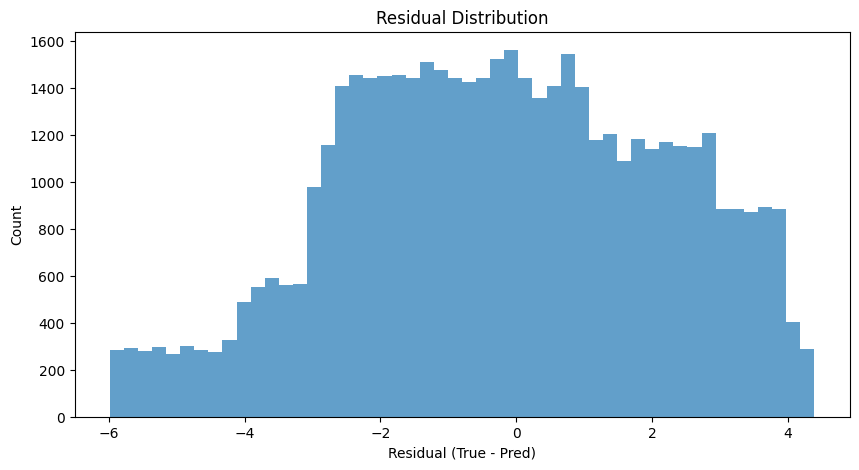

In [ ]:
residuals = y_test_rescaled - y_pred_rescaled
plt.figure(figsize=(10,5))
plt.hist(residuals.flatten(), bins=50, alpha=0.7)
plt.xlabel("Residual (True - Pred)")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.show()


In [ ]:
y_shuffled = np.random.permutation(y_train)

# Train again for a few epochs with shuffled labels
history_shuf = model.fit(
    X_train, y_shuffled,
    validation_data=(X_val, y_val),
    epochs=5, batch_size=64, verbose=1
)

# Evaluate performance
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print("Performance with shuffled labels -> Loss:", loss, "MAE:", mae)

Epoch 1/5
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 1.8855 - mae: 1.1216 - val_loss: 0.0850 - val_mae: 0.1825
Epoch 2/5
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.8522 - mae: 1.1121 - val_loss: 0.0873 - val_mae: 0.1864
Epoch 3/5
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.8187 - mae: 1.1024 - val_loss: 0.0903 - val_mae: 0.1921
Epoch 4/5
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.7944 - mae: 1.0953 - val_loss: 0.0945 - val_mae: 0.1986
Epoch 5/5
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 1.7727 - mae: 1.0892 - val_loss: 0.0996 - val_mae: 0.2066
Performance with shuffled labels -> Loss: 0.10102362930774689 MAE: 0.20839832723140717
